# 1. Data Preprocessing 

### Outline of this notebook:
* **Section 1:** Objective
* **Section 2:** Data loading and initial inspection
* **Section 3:** Define and examine target variable (default)
* **Section 4:** Remove leakage variables and high-missingness features
* **Section 5:** Data cleaning and variable formatting
* **Section 6:** Save cleaned dataset 

---
## Section 1: Objective

In this notebook, we prepare the LendingClub loan dataset (2007Q3–2020Q3) for modeling. The goal is to construct a clean, analysis-ready dataset for default prediction.

The raw data includes approved (funded) loans and contains detailed loan-level information:
- **Borrower characteristics:** e.g., `annual_inc`, `emp_length`, `home_ownership`, `zip_code`  
- **Credit history:** e.g., `fico_range_low`, `fico_range_high`, `dti`, `delinq_2yrs`  
- **Loan terms:** e.g., `loan_amnt`, `term`, `int_rate`  
- **Outcomes:** e.g., `loan_status`, `recoveries`, `last_pymnt_amnt`  

We focus on:
- Defining a clear **default outcome variable**  
- Removing **data leakage variables** and features with high missingness  
- Cleaning and formatting variables for downstream modeling  

The final output of this notebook is a cleaned dataset that can be used for predictive modeling in subsequent analyses.

--- 
## Section 2: Data loading and initial inspection

In [4]:
import pandas as pd 
import matplotlib.pyplot as plt
import sys
import os

In [5]:
df_raw = pd.read_csv("../data/raw/Loan_status_2007-2020Q3.gzip")

/var/folders/61/4f46qg1x30s7x09xxzgv1qb40000gn/T/ipykernel_26019/2965388665.py:1: DtypeWarning: Columns (1,48,58,117,127,128,129,132,133,134,137) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv("../data/raw/Loan_status_2007-2020Q3.gzip")


In [6]:
df_raw.head()

,Unnamed: 0,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag
0,0,1077501,5000.0,5000.0,4975.0,36 months,10.65%,162.87,B,B2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
1,1,1077430,2500.0,2500.0,2500.0,60 months,15.27%,59.83,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
2,2,1077175,2400.0,2400.0,2400.0,36 months,15.96%,84.33,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
3,3,1076863,10000.0,10000.0,10000.0,36 months,13.49%,339.31,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
4,4,1075358,3000.0,3000.0,3000.0,60 months,12.69%,67.79,B,B5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N


In [7]:
df_raw.shape

(2925493, 142)

In [8]:
df_raw['issue_d'].head()

0    Dec-2011
1    Dec-2011
2    Dec-2011
3    Dec-2011
4    Dec-2011
Name: issue_d, dtype: object

In [9]:
df_raw['issue_d'] = pd.to_datetime(df_raw['issue_d'], format='%b-%Y', errors='coerce')
df_raw['issue_d'].min(), df_raw['issue_d'].max()

(Timestamp('2007-06-01 00:00:00'), Timestamp('2020-09-01 00:00:00'))

---
## Section 3: Define and examine target variable (default)

We begin by defining and examining the target variable used for prediction. Since the goal of this project is to model credit risk, it is essential to first construct a clear definition of default based on the available loan outcome information.

The `loan_status` variable describes the current or final state of each loan. It includes both final outcomes (e.g., fully repaid or defaulted) and intermediate states (e.g., ongoing or delinquent loans). Click [here](https://www.lendingclub.com/help/investing-faq/what-do-the-different-note-statuses-mean) for more information about each status.

#### Interpretation of categories:
* **Fully Paid:** Loan has been completely repaid  <span style="color:green">(non-default)</span>
* **Charged Off:** Loan is written off after severe delinquency <span style="color:red">(default)</span>
* **Default:** Loan is in default but not yet fully charged off <span style="color:red">(default)</span>
* **Current:** Loan is ongoing and being paid on time (outcome not yet known)
* **Late (16–30 days):** Borrower is slightly behind on payments
* **Late (31–120 days):** Borrower is significantly delinquent
* **In Grace Period:** Payment is slightly overdue but within grace period
* **Issued:** Loan has been issued but no payment history yet
* **Does not meet credit policy. Status:Fully Paid:** Borrower did not meet standard criteria but repaid loan 
* **Does not meet credit policy. Status:Charged Off:** Borrower did not meet criteria and defaulted 

#### Target definition for modeling: 
We restrict the sample to **resolved loans only** (i.e., loans with known final outcomes) to avoid censoring issues from ongoing loans.
<br>Specifically, to construct a clean binary target for credit risk prediction:
* **Default (1):**
    * Charged Off
    * Default
* **Non-default (0):**
    * Fully Paid
* **Excluded (drop from sample):**
    * Current
    * Late (16–30 days), Late (31–120 days)
    * In Grace Period
    * Issued
    * Does not meet credit policy. Status:Charged Off
    * Does not meet credit policy. Status:Fully Paid

Below, I explore the distribution of loan status.

In [11]:
## --- Examine missing value 
n_missing = df_raw['loan_status'].isna().sum()
print(f"Number of missing values in loan_status: {int(n_missing)}")

Number of missing values in loan_status: 1


In [12]:
# df_raw[df_raw['loan_status'].isna()]
# => Browsing shows that missing loan_status comes from loans that do not meet the credit policy. 

In [13]:
## --- Loan status distribution (among all observations) 
counts = df_raw['loan_status'].value_counts()
percent = df_raw['loan_status'].value_counts(normalize=True) * 100

pd.DataFrame({'count': counts, 'percent': percent})

,count,percent
loan_status,,
Fully Paid,1497783,51.197645
Current,1031016,35.242482
Charged Off,362548,12.392719
Late (31-120 days),16154,0.552181
In Grace Period,10028,0.342780
Late (16-30 days),2719,0.092942
Issued,2062,0.070484
Does not meet the credit policy. Status:Fully Paid,1988,0.067954
Does not meet the credit policy. Status:Charged Off,761,0.026013


#### Drop observations with the excluded `loan_status` categories

In [15]:
# define excluded categories
exclude = ['Current', 'Late (16-30 days)', 'Late (31-120 days)', 
           'In Grace Period', 'Issued',
           'Does not meet the credit policy. Status:Charged Off', 
           'Does not meet the credit policy. Status:Fully Paid']

# filter data => Going to use the filtered data from here on. 
df_filtered = df_raw.loc[~df_raw['loan_status'].isin(exclude)].copy()

In [16]:
# Define default variable 
df_filtered['default'] = df_filtered['loan_status'].isin(['Charged Off', 'Default']).astype(int)

In [17]:
# compute distribution
counts = df_filtered['default'].value_counts()
percent = df_filtered['default'].value_counts(normalize=True) * 100

pd.DataFrame({'count': counts, 'percent': percent})

,count,percent
default,,
0,1497784,80.492916
1,362981,19.507084


#### Key observation: 

After excluding ongoing and uncertain statuses (e.g., _Current, Late, Grace Period, Issued_), the data consists of:
* about 80.5% of non-default loans
* about 19.5% of default loans

---
## Section 4: Remove leakage variables and high-missingness features

### 🔷 Identify and remove leakage variables

A **leakage variable** is any feature that contains information not available at loan origination or is directly influenced by the loan outcome (default). Because our goal is to predict default given information at the time of loan approval, we need to exclude anything observed **after origination.**

To identify which variables may introduce leakage, it is useful to consider the loan approval process on LendingClub:
* A borrower applies → LendingClub evaluates credit risk (using income, credit history, etc.) → if approved, the loan is assigned a grade and listed on the platform.
* Only **after this approval and grading step** does the loan become visible to investors, who then decide whether to fund it based on available information (e.g., interest rate, grade, borrower profile).

Given this setup, leakage variables typically include any features that reflect post-origination loan performance or realized outcomes. These may capture:
* repayment behavior (e.g., total payments made, last payment amount)
* delinquency progression (e.g., past-due status, remaining balance)
* recovery after default
  
Such variables are either directly determined by the default outcome or evolve over time as the loan performs, making them unavailable at the time of prediction. Including them would lead to overly optimistic model performance that would not generalize out-of-sample.

#### Define a list of leakage variables

In [21]:
# initialize empty list
leakage_vars = []

# 1. Direct outcome / payment variables
leakage_vars += [
    'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee',
    'last_pymnt_amnt', 'last_pymnt_d'
]

# 2. Outstanding balance
leakage_vars += [
    'out_prncp', 'out_prncp_inv'
]

# 3. Post-origination credit updates
leakage_vars += [
    'last_credit_pull_d',
    'last_fico_range_low', 'last_fico_range_high'
]

# 4. Payment schedule / future info
leakage_vars += [
    'next_pymnt_d'
]

# 5. Hardship / restructuring variables
leakage_vars += [
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
    'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date',
    'payment_plan_start_date', 'hardship_length', 'hardship_dpd',
    'hardship_loan_status', 'orig_projected_additional_accrued_interest',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
    'pymnt_plan'
]

# 6. Debt settlement variables
leakage_vars += [
    'debt_settlement_flag', 'debt_settlement_flag_date',
    'settlement_status', 'settlement_date', 'settlement_amount',
    'settlement_percentage', 'settlement_term'
]

# 7. (Conservative drop) Collections / charge-off related
leakage_vars += [
    'tot_coll_amt', 'collections_12_mths_ex_med', 
    'chargeoff_within_12_mths', 
]

# 8. Other variables (timing ambiguity)
## ['delinq_amnt', 'delinq_2yrs', 'inq_last_6mths', 'acc_now_delinq', 'tax_liens']
## ['mths_since_last_delinq', 'mths_since_last_major_derog', 'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq']
## => These variables reflect borrower credit conditions, 
##    but it is not always clear whether they are strictly measured at origination. 
##    Some projects include them as standard credit risk features, 
##    while others exclude them out of caution regarding potential timing or update issues.

# Remove duplicates just in case
leakage_vars = list(set(leakage_vars))

#### Remove leakage variables from data 

In [23]:
## count leakage variables
len(leakage_vars)

41

In [24]:
df_cleaned = df_filtered.drop(columns=leakage_vars, errors='ignore').copy()

df_cleaned.shape

(1860765, 108)

### 🔷 Identify variables with high missingness

We next remove variables with a high proportion of missing values to improve data quality and model reliability. Features with substantial missingness (e.g., ≥30%) can introduce noise and reduce statistical power. While some missingness may be informative, many highly incomplete variables provide limited additional signal relative to the complexity they add. Therefore, we drop these variables to ensure a cleaner, more stable modeling dataset.

In [26]:
# 1. Compute missingness ratio
missing_ratio = df_cleaned.isnull().mean()

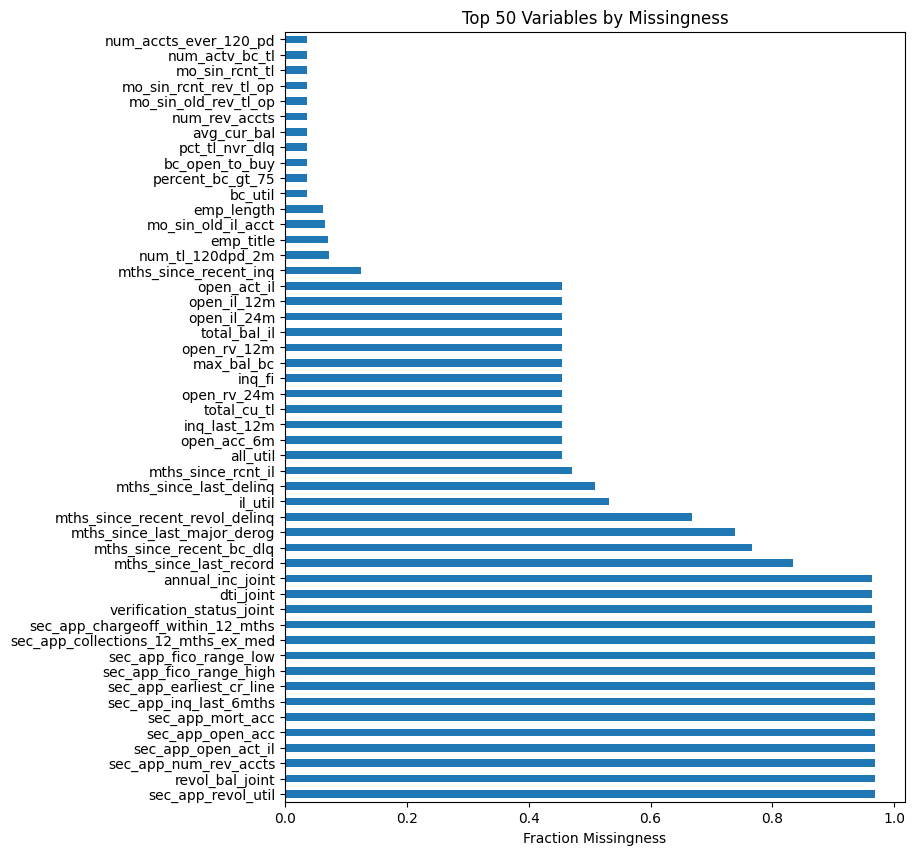

In [27]:
missing_ratio.sort_values(ascending=False).head(50).plot(kind='barh', figsize=(8,10))
plt.title("Top 50 Variables by Missingness")
plt.xlabel("Fraction Missingness")
plt.show()

#### Observations:
The distribution of missing values reveals that a subset of variables exhibits very high missingness, often exceeding 80–90%. 
* In particular, variables related to joint applications (e.g., `annual_inc_joint`, `dti_joint`, `verification_status_joint`, and all `sec_app_*` features) are almost entirely missing, as most loans are individual rather than joint applications.
* Additionally, several credit history timing variables (e.g., `mths_since_last_record`, `mths_since_recent_bc_dlq`, `mths_since_last_major_derog`) also show substantial missingness, likely because these events do not occur for many borrowers.

Given their limited coverage, these variables are strong candidates for removal to ensure a more reliable and stable modeling dataset.

In [29]:
# 2. Identify variables with >= 30% missing
high_missing_vars = missing_ratio[missing_ratio >= 0.30].index.tolist()
print(f"Number of variables with >=30% missing: {len(high_missing_vars)}")

Number of variables with >=30% missing: 34


In [30]:
# 3. Drop them
df_cleaned = df_cleaned.drop(columns=high_missing_vars)

# Check remaining shape
print(df_cleaned.shape)

(1860765, 74)


In [31]:
## list remaining variables 
#list(df_cleaned.columns)

---
## Section 5: Data Cleaning and Variable Formatting

In this section, we clean and standardize raw variables in `df_cleaned` to ensure they are in a consistent, model-ready format.
* First, we convert string-formatted variables such as `term`, `int_rate`, and `revol_util` into numeric values. We also map categorical variables with natural ordering, such as `emp_length`, into numeric representations.
* Second, we process date variables: `earliest_cr_line` is transformed into a continuous measure of credit history length (`credit_age`), and `issue_d` is converted to datetime format for time-based splitting.
* Finally, we drop irrelevant or redundant variables, including identifiers (`id`, `url`), free-text fields (`emp_title`, `title`), and variables that are either duplicates or not available at prediction time (e.g., `funded_amnt`, `funded_amnt_inv`, `loan_status`). This helps prevent data leakage and reduces unnecessary noise in the model.

These steps ensure that all features are properly formatted, relevant, and ready for downstream preprocessing and modeling.

### 🔷 Change variable formats 

In [34]:
# -----------------------------
# Convert string-formatted variables
# -----------------------------
# 1. term: "36 months" → 36
if "term" in df_cleaned.columns:
    df_cleaned["term"] = df_cleaned["term"].str.extract(r"(\d+)").astype(float)

# 2. int_rate: "10.65%" → 0.1065
if "int_rate" in df_cleaned.columns:
    df_cleaned["int_rate"] = df_cleaned["int_rate"].str.rstrip("%").astype(float) / 100

# 3. revol_util: "83.7%" → 0.837
if "revol_util" in df_cleaned.columns:
    df_cleaned["revol_util"] = df_cleaned["revol_util"].str.rstrip("%").astype(float) / 100


In [35]:
# -----------------------------
# Convert categorical → numeric
# -----------------------------
#df_cleaned["emp_length"].value_counts(dropna=False)

In [36]:
# 4. emp_length: "< 1 year", "10+ years" → numeric
emp_map = {
    "< 1 year": 0.5,
    "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4,
    "5 years": 5, "6 years": 6, "7 years": 7, "8 years": 8,
    "9 years": 9, "10+ years": 10
}

if "emp_length" in df_cleaned.columns:
    df_cleaned["emp_length"] = df_cleaned["emp_length"].map(emp_map)
    # Unmapped values → NaN (handled later by imputer)

#df_cleaned["emp_length"].value_counts(dropna=False)

In [37]:
# -----------------------------
# Date handling
# -----------------------------
# 5. earliest_cr_line → credit age (years)
if "earliest_cr_line" in df_cleaned.columns:
    df_cleaned["earliest_cr_line"] = pd.to_datetime(df_cleaned["earliest_cr_line"], errors="coerce")
    df_cleaned["credit_age"] = (
        (pd.to_datetime("today") - df_cleaned["earliest_cr_line"]).dt.days / 365
    )
    df_cleaned = df_cleaned.drop(columns=["earliest_cr_line"])

# 6. issue_d → datetime (for time-based split)
if "issue_d" in df_cleaned.columns:
    df_cleaned["issue_d"] = pd.to_datetime(df_cleaned["issue_d"], errors="coerce")

/var/folders/61/4f46qg1x30s7x09xxzgv1qb40000gn/T/ipykernel_26019/1153051577.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_cleaned["earliest_cr_line"] = pd.to_datetime(df_cleaned["earliest_cr_line"], errors="coerce")


### 🔷 Drop irrelevant variables 

The following variables are dropped as they do not provide meaningful predictive signal or may introduce noise/redundancy:

- **Identifiers**
  - `Unnamed: 0`, `id`
- **Non-informative fields**
  - `url`
- **Redundant variables**
  - `funded_amnt`, `funded_amnt_inv` (overlap with `loan_amnt`)
  - `fico_range_high` (duplicate of `fico_range_low`)
  - `loan_status` (redundant to `default` -- generated target variable)
- **Low-variation / platform-specific**
  - `policy_code`
- **Unstructured text (excluded for simplicity)**
  - `emp_title`, `title`

These are excluded to reduce noise and focus on economically meaningful features for prediction.

In [39]:
irrelevant_vars = ['Unnamed: 0', 'id', 'url', 'loan_status', 'emp_title', 'title',
                    'funded_amnt', 'funded_amnt_inv', 'fico_range_high', 'policy_code']

df_cleaned = df_cleaned.drop(columns=irrelevant_vars)

# Check remaining shape
print(df_cleaned.shape)

(1860765, 64)


---
## Section 6: Save cleaned dataset

In [41]:
# save file
df_cleaned.to_parquet("../data/processed/LendingClub_cleaned.parquet", index=False)